In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
#### Summary
# clustering method I tried:
  ## tried

In [3]:
import pandas as pd

df = pd.read_parquet("all_features.parquet")

print(df.shape)
df.head()

(61410, 53)


,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


In [8]:
print("Total rows:", len(df))

print("\nLabel counts:")
print(df["label"].value_counts(dropna=False))

print("\nLabeled rows:", df["label"].notna().sum())
print("Unlabeled rows:", df["label"].isna().sum())

Total rows: 61410

Label counts:
label
NaN    60410
0.0      990
1.0       10
Name: count, dtype: int64

Labeled rows: 1000
Unlabeled rows: 60410


In [9]:
# Seperate labeled and unlabeled
df_labeled = df[df["label"].notna()].copy()
df_unlabeled = df[df["label"].isna()].copy()

In [14]:
# check missing value
import numpy as np

print("Any NaN in df?", df.isna().any().any())
print("NaN count total:", df.isna().sum().sum())

X = df.drop(columns=["label"])
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("NaN count in X:", X.isna().sum().sum())

Any NaN in df? True
NaN count total: 303136
X shape: (61410, 50)
NaN count in X: 242726


In [21]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# 1. drop identifier and label
X = df.drop(columns=["customer_id", "label"])

# 2. one-hot encode categorical
X = pd.get_dummies(X, columns=["customer_type", "occupation_sector_id"], drop_first=True)

# 3. keep numeric only (safety)
X = X.select_dtypes(include=["number"])


In [23]:
## Input missing -- median
# (A) median impute
imputer_median = SimpleImputer(strategy="median")
X_imputed_median = imputer_median.fit_transform(X)

# (B) scale
scaler_median = StandardScaler()
X_scaled_median = scaler_median.fit_transform(X_imputed_median)

# (C) kmeans
kmeans_median = KMeans(n_clusters=5, random_state=42, n_init="auto")
df["cluster_median"] = kmeans_median.fit_predict(X_scaled_median)

# (D) view cluster sizes
df["cluster_median"].value_counts()

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,count
cluster_median,
0,38501
1,22495
3,411
4,2
2,1


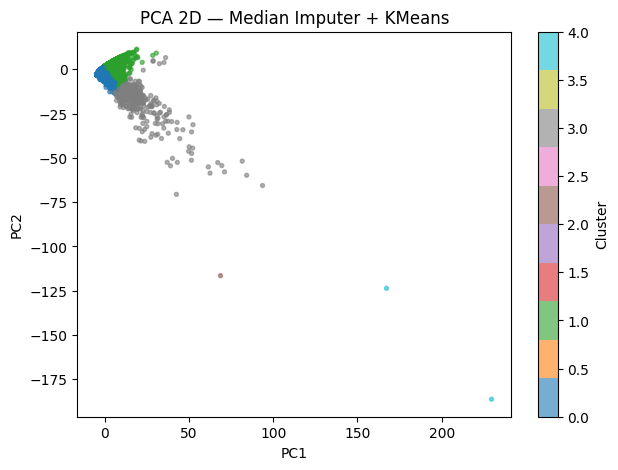

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled_median)

plt.figure(figsize=(7,5))
sc = plt.scatter(coords[:,0], coords[:,1], c=df["cluster_median"], cmap="tab10", alpha=0.6, s=8)
plt.title("PCA 2D — Median Imputer + KMeans")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="Cluster")
plt.show()

In [42]:
from sklearn.impute import KNNImputer

# (A) knn impute
imputer_knn = KNNImputer(n_neighbors=5, weights="distance")
X_imputed_knn = imputer_knn.fit_transform(X)

# (B) scale
scaler_knn = StandardScaler()
X_scaled_knn = scaler_knn.fit_transform(X_imputed_knn)

# (C) kmeans
kmeans_knn = KMeans(n_clusters=5, random_state=42, n_init="auto")
df["cluster_knn"] = kmeans_knn.fit_predict(X_scaled_knn)

# (D) view cluster sizes
df["cluster_knn"].value_counts()


KeyboardInterrupt: 

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled_knn)

plt.figure(figsize=(7,5))
sc = plt.scatter(coords[:,0], coords[:,1], c=df["cluster_knn"], cmap="tab10", alpha=0.6, s=8)
plt.title("PCA 2D — KNN Imputer + KMeans")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(sc, label="Cluster")
plt.show()

In [26]:
cluster_col = "cluster_median"

In [27]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

In [28]:
# with lables
df_labeled = df.dropna(subset=["label"]).copy()

drop_cols = ["customer_id"]
X_all = df_labeled.drop(columns=drop_cols + ["label"], errors="ignore")

# cluster as catergory
X_all[cluster_col] = X_all[cluster_col].astype("category")

y = df_labeled["label"].astype(int)

In [36]:
X_all = X_all.dropna(axis=1, how="all")

#  numeric / categorical
cat_cols = X_all.select_dtypes(include=["object","category","bool"]).columns.tolist()
num_cols = [c for c in X_all.columns if c not in cat_cols]

# numeric -> median impute; categorical -> most_frequent + onehot
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# Logistic Regression
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)


proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)

print("AUC:", auc)
print("Average Precision (PR-AUC):", ap)


AUC: 0.6414141414141414
Average Precision (PR-AUC): 0.09052757793764987


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:

def train_eval(X_df, y):
    # Dynamically determine numeric and categorical columns for the current X_df
    cat_cols = X_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X_df.columns if c not in cat_cols]

    # Re-create the preprocessor for the current X_df
    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )

    # Re-create the full pipeline for the current X_df
    clf_local = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=42, stratify=y
    )
    clf_local.fit(X_train, y_train)
    proba = clf_local.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, proba), average_precision_score(y_test, proba)

# (A) with cluster
X_with = X_all.copy()
auc_with, ap_with = train_eval(X_with, y)

# (B) without cluster
X_without = X_all.drop(columns=[cluster_col], errors="ignore")
auc_wo, ap_wo = train_eval(X_without, y)

print("WITH cluster  -> AUC:", auc_with, " PR-AUC:", ap_with)
print("WITHOUT cluster -> AUC:", auc_wo, " PR-AUC:", ap_wo)
print("Delta AUC:", auc_with - auc_wo, " Delta PR-AUC:", ap_with - ap_wo)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


WITH cluster  -> AUC: 0.38636363636363635  PR-AUC: 0.012132231404958678
WITHOUT cluster -> AUC: 0.40404040404040403  PR-AUC: 0.012385964912280702
Delta AUC: -0.01767676767676768  Delta PR-AUC: -0.0002537335073220237


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
!pip -q install lightgbm

In [39]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

cluster_col = "cluster_median"

df_labeled = df.dropna(subset=["label"]).copy()
y = df_labeled["label"].astype(int)


X_base = df_labeled.drop(columns=["customer_id","label"], errors="ignore").copy()


if cluster_col in X_base.columns:
    X_base[cluster_col] = X_base[cluster_col].astype("category")

X_base = X_base.dropna(axis=1, how="all")


In [40]:
def train_eval_lgbm(X, y):

    X = X.copy()

    for c in X.select_dtypes(include=["object"]).columns:
        X[c] = X[c].astype("category")


    num_cols = X.select_dtypes(include=["number"]).columns
    if len(num_cols) > 0:
        imp = SimpleImputer(strategy="median")
        X[num_cols] = imp.fit_transform(X[num_cols])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / max(pos, 1))

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=spw
    )

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    return auc, ap


In [41]:
# WITH cluster
X_with = X_base.copy()
auc_with, ap_with = train_eval_lgbm(X_with, y)

# WITHOUT cluster
X_wo = X_base.drop(columns=[cluster_col], errors="ignore")
auc_wo, ap_wo = train_eval_lgbm(X_wo, y)

print("WITH cluster    -> AUC:", auc_with, " PR-AUC:", ap_with)
print("WITHOUT cluster -> AUC:", auc_wo, " PR-AUC:", ap_wo)
print("Delta AUC:", auc_with - auc_wo, " Delta PR-AUC:", ap_with - ap_wo)


[LightGBM] [Info] Number of positive: 8, number of negative: 792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6377
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [43]:
!pip -q install imbalanced-learn


In [44]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer

cluster_col = "cluster_median"

df_labeled = df.dropna(subset=["label"]).copy()
y = df_labeled["label"].astype(int)

X_base = df_labeled.drop(columns=["customer_id","label"], errors="ignore").copy()

if cluster_col in X_base.columns:
    X_base[cluster_col] = X_base[cluster_col].astype("category")

X_base = X_base.dropna(axis=1, how="all")

# one-hot encode categorical
X_base = pd.get_dummies(X_base, drop_first=True)

# median impute
imp = SimpleImputer(strategy="median")
X_base = pd.DataFrame(imp.fit_transform(X_base), columns=X_base.columns)


In [45]:
from imblearn.ensemble import BalancedRandomForestClassifier

def train_eval_brf(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = BalancedRandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    return auc, ap


In [46]:
# WITH cluster
X_with = X_base.copy()
auc_with, ap_with = train_eval_brf(X_with, y)

# WITHOUT cluster
X_wo = X_base.drop(columns=[c for c in X_base.columns if cluster_col in c], errors="ignore")
auc_wo, ap_wo = train_eval_brf(X_wo, y)

print("Balanced RF WITH cluster    -> AUC:", auc_with, " PR-AUC:", ap_with)
print("Balanced RF WITHOUT cluster -> AUC:", auc_wo, " PR-AUC:", ap_wo)

print("Delta AUC:", auc_with - auc_wo)
print("Delta PR-AUC:", ap_with - ap_wo)


Balanced RF WITH cluster    -> AUC: 0.38636363636363635  PR-AUC: 0.011866623079437724
Balanced RF WITHOUT cluster -> AUC: 0.46969696969696967  PR-AUC: 0.013936216688510267
Delta AUC: -0.08333333333333331
Delta PR-AUC: -0.002069593609072544


In [ ]:
# =====================================
# Experiment different number of clusters (k)
# =====================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    cluster_labels = kmeans.fit_predict(X_scaled_median)

    # Silhouette score (cluster quality)
    sil = silhouette_score(X_scaled_median, cluster_labels)

    # Fraud rate separation (most important for AML)
    df_temp = df.copy()
    df_temp["cluster_test"] = cluster_labels

    fraud_rates = df_temp.groupby("cluster_test")["label"].mean()

    fraud_std = fraud_rates.std()

    results.append({
        "k": k,
        "silhouette_score": sil,
        "fraud_rate_std": fraud_std
    })

# Convert to dataframe
results_df = pd.DataFrame(results)

# Sort by fraud separation (most useful)
results_df = results_df.sort_values("fraud_rate_std", ascending=False)

results_df


In [51]:
k = 7

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

cluster_labels = kmeans.fit_predict(X_scaled_median)

# add cluster to dataframe
df_inspect = df.copy()
df_inspect["cluster_7"] = cluster_labels

# total samples per cluster
cluster_counts = df_inspect["cluster_7"].value_counts().sort_index()

# fraud count per cluster
fraud_counts = df_inspect.groupby("cluster_7")["label"].sum()

# fraud rate per cluster
fraud_rates = df_inspect.groupby("cluster_7")["label"].mean()

# combine into table
cluster_summary = pd.DataFrame({
    "total_customers": cluster_counts,
    "fraud_count": fraud_counts,
    "fraud_rate": fraud_rates
})

# sort by fraud_rate descending
cluster_summary = cluster_summary.sort_values("fraud_rate", ascending=False)

cluster_summary

,total_customers,fraud_count,fraud_rate
cluster_7,,,
5,2436,3.0,0.111111
6,20834,3.0,0.012295
0,30078,4.0,0.005874
1,7822,0.0,0.000000
2,1,0.0,NaN
3,237,0.0,NaN
4,2,0.0,NaN


In [50]:
# =====================================
# Inspect fraud distribution for k = 2 to 10
# =====================================

from sklearn.cluster import KMeans

all_cluster_results = {}

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    cluster_labels = kmeans.fit_predict(X_scaled_median)

    df_temp = df.copy()
    df_temp["cluster"] = cluster_labels

    cluster_summary = df_temp.groupby("cluster").agg(
        total_customers=("label", "count"),
        fraud_count=("label", "sum"),
        fraud_rate=("label", "mean")
    )

    cluster_summary = cluster_summary.sort_values(
        "fraud_rate",
        ascending=False
    )

    all_cluster_results[k] = cluster_summary

    print("\n=============================")
    print(f"K = {k}")
    print("=============================")
    print(cluster_summary)



K = 2
         total_customers  fraud_count  fraud_rate
cluster                                          
0                   1000         10.0        0.01
1                      0          0.0         NaN

K = 3
         total_customers  fraud_count  fraud_rate
cluster                                          
1                    196          2.0    0.010204
0                    804          8.0    0.009950
2                      0          0.0         NaN

K = 4
         total_customers  fraud_count  fraud_rate
cluster                                          
0                    783          8.0    0.010217
1                    217          2.0    0.009217
2                      0          0.0         NaN
3                      0          0.0         NaN

K = 5
         total_customers  fraud_count  fraud_rate
cluster                                          
0                    783          8.0    0.010217
1                    217          2.0    0.009217
2                     